CI      0
IPVI    0
NDVI    0
CGMI    0
dtype: int64
CI      0
IPVI    0
NDVI    0
CGMI    0
dtype: int64


C:\Users\马明杰\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


TMSE: 0.0059346430374782435
TRMSE: 0.07703663438571445
TMAE: 0.060883529109936954
TMAPE: 10.006136245155108
TR²: 0.6398078158627
TRMSRE: 0.13772557778151184
bias1: 0.0002659622158163907
bias2: 0.008624031371339162
VMSE: 0.004845580661169179
VRMSE: 0.069610205151035
VMAE: 0.05669256506107102
VMAPE: 9.379807894163227
VR²: 0.6113570181208935
VRMSRE: 0.12025938677235166


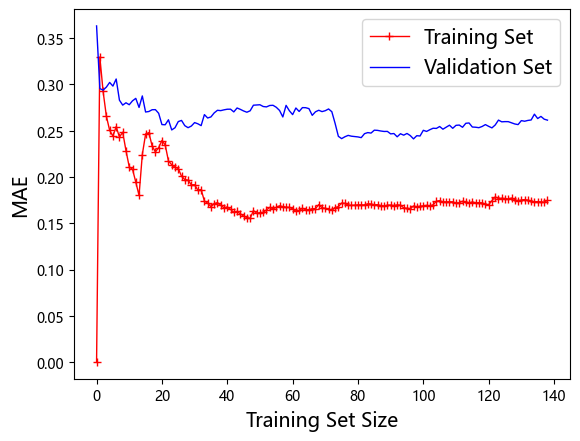

      y_train    y_pred
187  0.541077  0.593263
60   0.758400  0.741102
94   0.708521  0.640655
43   0.720973  0.840014
163  0.751467  0.738385
..        ...       ...
67   0.815720  0.759493
159  0.623781  0.600324
114  0.580623  0.624207
157  0.385551  0.481478
91   0.795609  0.639595

[140 rows x 2 columns]


In [59]:
import time
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.datasets import make_classification
import matplotlib #主要用来作图 
import matplotlib.pyplot as plt ##主要用来作图
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


import time

matplotlib.rc("font", family='Microsoft YaHei') #使得图像中可以显示中文，字体微软雅黑
dataset=pd.read_excel(r"E:\论文5\a\特征优化 EWM\0908\UAV0908.xlsx",na_values=['NA', '?', -999])
#dataset = dataset.astype(float)
dataset.head()
print(dataset.isnull().sum())  # 检查空值
print(dataset.isin([np.nan, np.inf, -np. inf]).sum())  # 检查NaN和Inf

X_1,y=dataset.iloc[:,:-1],dataset.iloc[:,-1]#可以表示x为除了最后一列，y为最后一列
# 归一化特征数据
scaler = StandardScaler()
X = scaler.fit_transform(X_1)

#print(X,y)#输出表示x，y
#print("X维度", X.shape)
#print("y维度",y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 90
                                                    
                                    
,shuffle=True)  # 5  35  52   41 126  101 174 184  _ 14 69 97 101 172 176  223  310 #179 234
#56 92 101 170 184 208 234
#101  140 78

# 使用早停法（防止过拟合）
eval_set = [(X_test, y_test)]

# XGBoost回归模型#(min_child_weight：每个叶子节点的最小权重，可以降低树的复杂度，防止过拟合)#（ alpha：L1正则化，防止过拟合）,
model = xgb.XGBRegressor(n_estimators= 124,
    max_depth=5,
    learning_rate=0.21,
    colsample_bytree=0.5,
    min_child_weight=4, 
    reg_alpha=0.05,  # L1正则 0.01 
    reg_lambda= 0.7,  # L2正则 0.1 0.7
    subsample=0.6)# 新增行采样


# 10折交叉验证
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')


#训练与早停
model.fit(X_train, y_train, early_stopping_rounds=10, eval_set=eval_set, verbose=False)
# 预测结果


# 预测结果
y2_pred = model.predict(X_test)
y_pred = model.predict(X_train)


def calculate_bias1(y_train, y_pred):
    y_true = np.array(y_train)
    y_pred = np.array(y_pred)
    return np.mean(y_pred - y_train)
def calculate_bias2(y_test, y2_pred):
    y_true = np.array(y_test)
    y_pred = np.array(y2_pred)
    return np.mean(y2_pred - y_test)

matplotlib.rc("font", family='Microsoft YaHei')  

# 计算评估指标
mse1 = mean_squared_error(y_train, y_pred)
rmse1 = np.sqrt(mse1)
mae1 = mean_absolute_error(y_train, y_pred)
mape1 = np.mean(np.abs((y_train - y_pred) / y_train)) * 100
r21 = r2_score(y_train, y_pred)
bias1 = calculate_bias1(y_train, y_pred)

mse2 = mean_squared_error(y_test, y2_pred)
rmse2 = np.sqrt(mse2)
mae2 = mean_absolute_error(y_test, y2_pred)
mape2 = np.mean(np.abs((y_test - y2_pred) / y_test)) * 100
r22 = r2_score(y_test, y2_pred)
RMSRE1 = np.sqrt(np.mean(((y_train - y_pred) / y_train) ** 2)) 
RMSRE2 = np.sqrt(np.mean(((y_test - y2_pred) / y_test) ** 2))  
bias2 = calculate_bias2(y_test, y2_pred)

print('TMSE:', mse1)
print('TRMSE:', rmse1)
print('TMAE:', mae1)
print('TMAPE:', mape1)
print('TR²:', r21)
print('TRMSRE:', RMSRE1)
print('bias1:', bias1)

print('bias2:', bias2)
print('VMSE:', mse2)
print('VRMSE:', rmse2)
print('VMAE:', mae2)
print('VMAPE:', mape2)
print('VR²:', r22)
print('VRMSRE:', RMSRE2)
# 在此处插入需要计时的代码

#绘制MAE损失曲线
train_errors, val_errors = [], []
for m in range(1, len(X_train)):
    model.fit(X_train[:m], y_train[:m])
    y_train_pred = model.predict(X_train[:m])
    y_val_pred = model.predict(X_test)
    train_errors.append(mean_absolute_error(y_train[:m], y_train_pred))
    val_errors.append(mean_absolute_error(y_test, y_val_pred))
plt.plot(np.sqrt(train_errors), "r-+", linewidth=1, label="Training Set")
plt.plot(np.sqrt(val_errors), "b-", linewidth=1, label="Validation Set")
plt.legend(loc="upper right", fontsize=14)
plt.xlabel("Training Set Size", fontsize=14)
plt.ylabel("MAE", fontsize=14)
plt.show()

#图形数据输出到指定文件
import pandas as pd

# 创建一个DataFrame对象
output_df = pd.DataFrame({'Training Set Size': range(1, len(X_train)),
                          'Training MAE': np.sqrt(train_errors),
                          'Validation MAE': np.sqrt(val_errors)})

# 将DataFrame写入Excel文件中的第一个工作表
with pd.ExcelWriter(r"E:\论文4\delete-XGBoost损失函数曲线.xlsx") as writer:
    output_df.to_excel(writer, sheet_name='Sheet1', index=False)

# 输出测试集预测值和真实值，并保存到Excel文件中
df = pd.DataFrame({'y_test': y_test, 'y_pred': y2_pred})
with pd.ExcelWriter(r"E:\论文5\a\特征优化 EWM\0610\100.xlsx") as writer:
    df.to_excel(writer, sheet_name='Sheet1', index=False)
# 输出测试集预测值和真实值，并保存到Excel文件中

df = pd.DataFrame({'y_train': y_train, 'y_pred': y_pred})
with pd.ExcelWriter(r"E:\论文5\a\特征优化 EWM\0610\200.xlsx") as writer:
    df.to_excel(writer, sheet_name='Sheet2', index=False)
## #writer.save()
print(df)
#在此处插入需要计时的代码

In [1]:
#####################################bayes_opt库实现贝叶斯优化，基于高斯，且只能用高斯过程，自定义采集函数（poi、ei、ucb）##########
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from bayes_opt import BayesianOptimization, util
import matplotlib.pyplot as plt
import matplotlib
import csv
import os
import time

# 设置中文字体
matplotlib.rc("font", family='Microsoft YaHei')

# 设置随机种子
Z =184 #39

# 输出目录
output_dir_path = r'D:\桌面文件\第六篇文章\output'
if not os.path.exists(output_dir_path):
    os.makedirs(output_dir_path)

def objective(n_estimators, max_depth, learning_rate, colsample_bytree, min_child_weight, subsample):
    """贝叶斯优化的目标函数"""
    # 加载数据集
    dataset = pd.read_excel(r"E:\论文5\a\特征优化_CV\0610\UAV0610.xlsx")
    
    # 准备数据
    X, y = dataset.iloc[:, :-1], dataset.iloc[:, -1]

    # 归一化特征数据
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 定义XGBoost回归器
    xgb_model = xgb.XGBRegressor(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        learning_rate=learning_rate,
        colsample_bytree=colsample_bytree,
        min_child_weight=int(min_child_weight),
        subsample=subsample,
        random_state=Z
    )

    # 计算交叉验证得分的负值
    cv_score = -cross_val_score(xgb_model, X_scaled, y, cv=5, 
                               scoring='neg_root_mean_squared_error').mean()

    # 保存当前trial的结果
    output_file_path = os.path.join(output_dir_path, f'trial_{len(os.listdir(output_dir_path))+1}.csv')
    with open(output_file_path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['params', 'value'])
        params_dict = {
            'n_estimators': int(n_estimators), 
            'max_depth': int(max_depth), 
            'learning_rate': learning_rate, 
            'colsample_bytree': colsample_bytree,
            'min_child_weight': min_child_weight,
            'subsample': subsample
        }
        writer.writerow([str(params_dict), cv_score])
    
    return cv_score

# 贝叶斯优化参数范围
pbounds = {
    'n_estimators': (10, 150), 
    'max_depth': (1, 10), 
    'learning_rate': (0.005, 0.5), 
    'colsample_bytree': (0.1, 1.0),
    'min_child_weight': (1, 10),
    'subsample': (0.1, 1)
}

# 创建优化器
optimizer = BayesianOptimization(
    f=objective,
    pbounds=pbounds,
    verbose=2,
    random_state=Z,
)

optimizer.set_gp_params(normalize_y=True)  # 设置高斯过程
acq_func = util.UtilityFunction(kind='poi', kappa=1.576, xi=0.0)  # 设置采集函数

# 开始优化
start_time = time.time()
optimizer.maximize(n_iter=3, acquisition_function=acq_func)

# 保存优化结果
rows = []
for i, result in enumerate(optimizer.res):  
    output_file_path = os.path.join(output_dir_path, f'trial_{i+1}.csv') 
    with open(output_file_path, 'r', encoding='utf-8') as f:
        reader = csv.reader(f)
        next(reader)  # 跳过表头
        row = [
            i+1, 
            result['target'], 
            result['params']['n_estimators'], 
            result['params']['max_depth'],
            result['params']['learning_rate'], 
            result['params']['colsample_bytree'], 
            result['params']['min_child_weight'],
            result['params']['subsample']
        ]
        rows.append(row)

df = pd.DataFrame(rows, columns=[
    'trial_number', 'value', 'n_estimators', 'max_depth', 
    'learning_rate', 'colsample_bytree', 'min_child_weight', 'subsample'
])
df.drop_duplicates(subset=['value'], keep='first', inplace=True)
df.to_excel(r"E:\text\测试1.xlsx", index=False)

best_params = optimizer.max['params']
best_value = optimizer.max['target']

print(f"Best params: {best_params}")
print(f"Best value: {best_value}")
print(f"Optimization time: {time.time() - start_time:.2f} seconds")

##################################################################
# 使用优化后的超参数训练XGBoost模型
##################################################################

def create_model_with_optimized_params(optimized_params, add_regularization=True):
    """使用优化后的参数创建XGBoost模型"""
    base_params = {
        'n_estimators': int(optimized_params['n_estimators']),
        'max_depth': int(optimized_params['max_depth']),
        'learning_rate': optimized_params['learning_rate'],
        'colsample_bytree': optimized_params['colsample_bytree'],
        'min_child_weight': int(optimized_params['min_child_weight']),
        'subsample': optimized_params['subsample'],
        'random_state': Z
    }
    
    # 可选：添加正则化参数防止过拟合
    if add_regularization:
        base_params.update({
            'reg_alpha': 0.01,  # L1正则化
            'reg_lambda': 0.9,  # L2正则化
        })
    
    return xgb.XGBRegressor(**base_params)

# 加载最终数据集
dataset = pd.read_excel(r"E:\论文5\a\特征选择\0820\UAV0820.xlsx", na_values=['NA', '?', -999])

# 数据预处理
print("数据基本信息:")
print(f"数据集形状: {dataset.shape}")
print(f"空值检查: {dataset.isnull().sum().sum()}")
print(f"无穷值检查: {dataset.isin([np.nan, np.inf, -np.inf]).sum().sum()}")

X_1, y = dataset.iloc[:, :-1], dataset.iloc[:, -1]

# 归一化特征数据
scaler = StandardScaler()
X = scaler.fit_transform(X_1)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=38, shuffle=True
)

print(f"训练集大小: {X_train.shape}")
print(f"测试集大小: {X_test.shape}")

# 使用贝叶斯优化得到的最佳参数创建模型
print("\n使用优化后的超参数:")
print(f"n_estimators: {int(best_params['n_estimators'])}")
print(f"max_depth: {int(best_params['max_depth'])}")
print(f"learning_rate: {best_params['learning_rate']:.4f}")
print(f"colsample_bytree: {best_params['colsample_bytree']:.4f}")
print(f"min_child_weight: {int(best_params['min_child_weight'])}")
print(f"subsample: {best_params['subsample']:.4f}")

model = create_model_with_optimized_params(best_params, add_regularization=True)

# 10折交叉验证
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
print(f"\n交叉验证MAE得分: {-cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# 训练模型（使用早停法防止过拟合）
eval_set = [(X_test, y_test)]
model.fit(X_train, y_train, early_stopping_rounds=10, eval_set=eval_set, verbose=False)

# 预测
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# 计算评估指标函数
def calculate_metrics(y_true, y_pred, prefix=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100  # 避免除零
    r2 = r2_score(y_true, y_pred)
    rmsre = np.sqrt(np.mean(((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8)) ** 2))
    
    metrics = {
        f'{prefix}MSE': mse,
        f'{prefix}RMSE': rmse,
        f'{prefix}MAE': mae,
        f'{prefix}MAPE': mape,
        f'{prefix}R²': r2,
        f'{prefix}RMSRE': rmsre
    }
    return metrics

# 计算训练集和测试集指标
train_metrics = calculate_metrics(y_train, y_pred_train, "T")
test_metrics = calculate_metrics(y_test, y_pred_test, "V")

# 打印结果
print("\n训练集性能指标:")
for metric, value in train_metrics.items():
    print(f'{metric}: {value:.4f}')

print("\n测试集性能指标:")
for metric, value in test_metrics.items():
    print(f'{metric}: {value:.4f}')

# 特征重要性分析
feature_importance = model.feature_importances_
feature_names = dataset.columns[:-1]  # 排除目标列

# 创建特征重要性DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\n前10个最重要的特征:")
print(importance_df.head(10))

# 绘制特征重要性图
plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'][:15], importance_df['importance'][:15])
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 绘制MAE损失曲线
train_errors, val_errors = [], []
step_size = max(1, len(X_train) // 50)  # 采样50个点

for m in range(1, len(X_train), step_size):
    # 使用相同的优化参数创建新模型
    temp_model = create_model_with_optimized_params(best_params, add_regularization=True)
    temp_model.fit(X_train[:m], y_train[:m])
    y_train_pred = temp_model.predict(X_train[:m])
    y_val_pred = temp_model.predict(X_test)
    train_errors.append(mean_absolute_error(y_train[:m], y_train_pred))
    val_errors.append(mean_absolute_error(y_test, y_val_pred))

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(X_train), step_size), np.sqrt(train_errors), "r-+", linewidth=1, label="Training Set")
plt.plot(range(1, len(X_train), step_size), np.sqrt(val_errors), "b-", linewidth=1, label="Validation Set")
plt.legend(loc="upper right", fontsize=14)
plt.xlabel("Training Set Size", fontsize=14)
plt.ylabel("MAE", fontsize=14)
plt.title("XGBoost Learning Curve (with Optimized Hyperparameters)")
plt.grid(True, alpha=0.3)
plt.show()

# 保存所有结果
output_df = pd.DataFrame({
    'Training Set Size': range(1, len(X_train), step_size),
    'Training MAE': np.sqrt(train_errors),
    'Validation MAE': np.sqrt(val_errors)
})

# 保存预测结果
train_df = pd.DataFrame({'y_train': y_train, 'y_pred': y_pred_train})
test_df = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred_test})

# 保存优化参数信息
params_df = pd.DataFrame([{
    'parameter': key,
    'value': value
} for key, value in best_params.items()])

# 使用ExcelWriter保存多个sheet
with pd.ExcelWriter(r"E:\论文5\a\特征优化\0820\XGBoost_optimized_results.xlsx") as writer:
    output_df.to_excel(writer, sheet_name='Learning_Curve', index=False)
    train_df.to_excel(writer, sheet_name='Train_Predictions', index=False)
    test_df.to_excel(writer, sheet_name='Test_Predictions', index=False)
    importance_df.to_excel(writer, sheet_name='Feature_Importance', index=False)
    params_df.to_excel(writer, sheet_name='Optimized_Parameters', index=False)

# 保存模型（可选）
# import joblib
# joblib.dump(model, r"E:\论文5\a\特征优化\0820\xgboost_optimized_model.pkl")

print("\n所有结果已保存完成！")
print(f"优化后的模型训练和评估完成，总用时: {time.time() - start_time:.2f} 秒")

|   iter    |  target   | colsam... | learni... | max_depth | min_ch... | n_esti... | subsample |
-------------------------------------------------------------------------------------------------


FileNotFoundError: [Errno 2] No such file or directory: 'E:\\论文5\\a\\特征优化_CV\\0610\\UAV0610.xlsx'

In [3]:
import time
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.datasets import make_classification
import matplotlib #主要用来作图 
import matplotlib.pyplot as plt ##主要用来作图
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import time

matplotlib.rc("font", family='Microsoft YaHei') #使得图像中可以显示中文，字体微软雅黑
dataset=pd.read_excel(r"E:\论文5\a\特征优化 CV\0610\UAV0610.xlsx",na_values=['NA', '?', -999])
#dataset = dataset.astype(float)
dataset.head()
print(dataset.isnull().sum())  # 检查空值
print(dataset.isin([np.nan, np.inf, -np.inf]).sum())  # 检查NaN和Inf

X_1,y=dataset.iloc[:,:-1],dataset.iloc[
:,-1]#可以表示x为除了最后一列，y为最后一列
# 归一化特征数据
scaler = StandardScaler()
X = scaler.fit_transform(X_1)
print(X,y)#输出表示x，y
print("X维度", X.shape)
print("y维度",y.shape)

IPVI     0
OSAVI    0
SAVI     0
CGMI     0
dtype: int64
IPVI     0
OSAVI    0
SAVI     0
CGMI     0
dtype: int64
[[-6.71241856e-01 -5.92897413e-01 -4.78113552e-01]
 [ 2.08848997e-01  2.06239475e-01  1.94051486e-01]
 [ 2.00829823e+00  1.94548698e+00  1.84295673e+00]
 [ 9.20779593e-01  8.71364439e-01  7.96133489e-01]
 [-1.22710554e+00 -1.19927560e+00 -1.15433339e+00]
 [-1.38594742e-01 -9.63964952e-02 -4.60144561e-02]
 [-9.17044217e-01 -8.68607053e-01 -7.97254131e-01]
 [ 4.56448272e-01  4.79203776e-01  4.96734006e-01]
 [ 8.22081627e-01  7.76783458e-01  7.07356743e-01]
 [ 8.01929736e-01  7.65639930e-01  7.06872863e-01]
 [ 2.29358859e+00  2.36751624e+00  2.43296622e+00]
 [ 1.85504243e+00  1.98678291e+00  2.13877305e+00]
 [ 2.41710161e+00  2.63776995e+00  2.91522351e+00]
 [ 1.80354928e+00  1.77266964e+00  1.70979161e+00]
 [ 1.84915561e+00  1.74921263e+00  1.60673733e+00]
 [ 7.07597278e-01  5.47229105e-01  3.60267476e-01]
 [ 1.61491744e+00  1.56606261e+00  1.48394808e+00]
 [-1.18566628e+00 -

In [1127]:
#####################################bayes_opt库实现贝叶斯优化，基于高斯，且只能用高斯过程，自定义采集函数（poi、ei、ucb）##########

import pandas as pd
import csv
import os
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from bayes_opt import BayesianOptimization
import numpy as np
from bayes_opt import util
start_time = time.time()
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import time
##################################################################
Z =45
# 750
# 5 13 19 22 24 48   # 20 24 27 38
##############################################################################
output_dir_path = r'D:\桌面文件\第六篇文章\output'
if not os.path.exists(output_dir_path):
   os.makedirs(output_dir_path)

def objective(n_estimators, max_depth, learning_rate, colsample_bytree,min_child_weight,subsample):
# 加载数据集
    dataset = pd.read_excel(r"E:\论文5\a\特征优化 CV\0610\UAV0610.xlsx")
    dataset.head()
    # 准备数据
    X, y = dataset.iloc[:,:-1], dataset.iloc[:,-1] 

# 归一化特征数据
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

# 定义XGBoost回归器
    xgb = XGBRegressor(
    n_estimators=int(n_estimators),
    max_depth=int(max_depth),
    learning_rate=learning_rate,
    colsample_bytree=colsample_bytree,
       min_child_weight= int(min_child_weight),
        subsample=subsample,
            random_state=Z
)

# 计算交叉验证得分的负值
    cv_score = -cross_val_score(xgb, X_scaled, y, cv=5, scoring='neg_root_mean_squared_error').mean()

# 保存当前trial的结果
    output_file_path = os.path.join(output_dir_path, f'trial_{len(os.listdir(output_dir_path))+1}.csv')
    with open(output_file_path, 'w', newline='', encoding='utf-8') as f:
        
        writer = csv.writer(f)
        writer.writerow(['params', 'value'])
        writer.writerow([{'n_estimators': int(n_estimators), 'max_depth': int(max_depth), 
                      'learning_rate': learning_rate, 'colsample_bytree': colsample_bytree,
                          'min_child_weight': min_child_weight,'subsample': subsample}, cv_score])
        return cv_score

pbounds = {'n_estimators': (10, 150), 'max_depth': (1, 10), 'learning_rate': (0.005, 0.5), 'colsample_bytree': (0.1, 1.0),
            'min_child_weight':(1,10),'subsample': (0.1,1)}
optimizer = BayesianOptimization(
    f=objective,
    pbounds=pbounds,
    verbose=2,
    random_state=Z,)

optimizer.set_gp_params(normalize_y=True)#设置高斯过程
acq_func = util.UtilityFunction(kind='poi', kappa=1.576, xi=0.0)#设置采集函数（ei、poi、ucb）
optimizer.maximize(n_iter=3, acquisition_function=acq_func)#设置迭代次数

rows = []
for i, result in enumerate(optimizer.res):  
    output_file_path = os.path.join(output_dir_path, f'trial_{i+1}.csv') 
    with open(output_file_path, 'r', encoding='utf-8') as f:
         reader = csv.reader(f)
         next(reader)  # 跳过表头
         row = [i+1, result['target'], result['params']['n_estimators'], result['params']['max_depth'],
         result['params']['learning_rate'], result['params']['colsample_bytree'], result['params']['min_child_weight'],
                result['params']['subsample']]
         rows.append(row)
df = pd.DataFrame(rows, columns=['trial_number', 'value', 'n_estimators', 'max_depth','learning_rate','colsample_bytree', 'min_child_weight','subsample'])
df.drop_duplicates(subset=['value'], keep='first', inplace=True)
df.to_excel(r"E:\text\测试1.xlsx", index=False)
best_params = optimizer.max['params']
best_value = optimizer.max['target']

print(f"Best params: {best_params}")
print(f"Best value: {best_value}")

#################################################XBGOOST######################################################################


|   iter    |  target   | colsam... | learni... | max_depth | min_ch... | n_esti... | subsample |
-------------------------------------------------------------------------------------------------
| 1         | 0.09373   | 0.9901    | 0.277     | 3.533     | 1.696     | 72.23     | 0.5255    |
| 2         | 0.08784   | 0.1437    | 0.08585   | 2.044     | 6.647     | 129.9     | 0.6851    |
| 3         | 0.1021    | 0.9916    | 0.2378    | 6.565     | 3.544     | 146.6     | 0.7058    |
| 4         | 0.0944    | 0.4965    | 0.1484    | 5.587     | 2.012     | 41.77     | 0.5307    |
| 5         | 0.1079    | 0.3185    | 0.1971    | 8.37      | 1.671     | 139.2     | 0.3024    |
| 6         | 0.108     | 0.3197    | 0.1972    | 8.372     | 1.67      | 139.3     | 0.3028    |
| 7         | 0.1051    | 0.2475    | 0.1443    | 7.88      | 1.449     | 140.0     | 0.329     |
| 8         | 0.1007    | 0.6325    | 0.2754    | 7.964     | 1.865     | 139.8     | 0.6562    |
Best params: {'colsa

CI       0
IPVI     0
NDVI     0
NPCI     0
SAVI     0
TCARI    0
CGMI     0
dtype: int64
CI       0
IPVI     0
NDVI     0
NPCI     0
SAVI     0
TCARI    0
CGMI     0
dtype: int64
TMSE: 0.009963279101918368
TRMSE: 0.0998162266463643
TMAE: 0.0778698045729351
TMAPE: 12.96267523162047
TR²: 0.5078900259004469
TRMSRE: 0.19630649859237242
VMSE: 0.010457153464894176
VRMSE: 0.10226022425603308
VMAE: 0.08108697135275252
VMAPE: 14.357284123619424
VR²: 0.4656048423251917
VRMSRE: 0.22483004376559587


C:\Users\马明杰\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


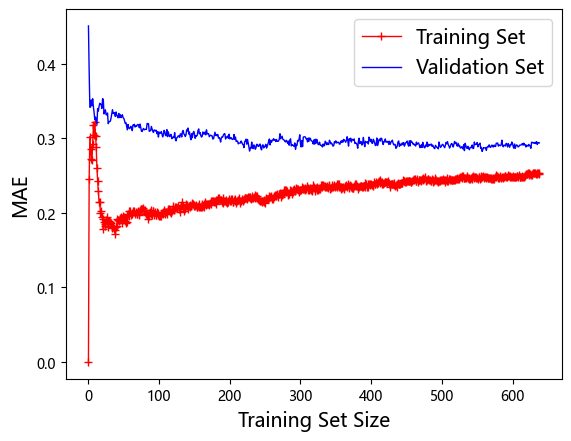

      y_train    y_pred
241  0.876696  0.745512
501  0.755552  0.723887
227  0.610079  0.718651
560  0.693706  0.708788
225  0.786321  0.745512
..        ...       ...
75   0.428491  0.547580
599  0.635610  0.713234
575  0.608726  0.671242
337  0.698895  0.727445
523  0.812284  0.723887

[640 rows x 2 columns]


In [15]:
################################################################XGBoost回归########################
import time
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.datasets import make_classification
import matplotlib #主要用来作图 
import matplotlib.pyplot as plt ##主要用来作图
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

import time

matplotlib.rc("font", family='Microsoft YaHei') #使得图像中可以显示中文，字体微软雅黑
dataset=pd.read_excel(r"E:\论文5\a\特征优化 CV\T\UAV.xlsx",na_values=['NA', '?', -999])
#dataset = dataset.astype(float)
dataset.head()
print(dataset.isnull().sum())  # 检查空值
print(dataset.isin([np.nan, np.inf, -np. inf]).sum())  # 检查NaN和Inf

X_1,y=dataset.iloc[:,:-1],dataset.iloc[:,-1]#可以表示x为除了最后一列，y为最后一列
# 归一化特征数据
scaler = StandardScaler()
X = scaler.fit_transform(X_1)

#print(X,y)#输出表示x，y
#print("X维度", X.shape)
#print("y维度",y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 101
                                                    
                                    
,shuffle=True)  # 5  35  52   41 126  101 174 184  _ 14 69 97 101 172 176  223  310 #179 234
#56 92 101 170 184 208 234
#101  140 78

# 使用早停法（防止过拟合）
eval_set = [(X_test, y_test)]

# XGBoost回归模型#(min_child_weight：每个叶子节点的最小权重，可以降低树的复杂度，防止过拟合)#（ alpha：L1正则化，防止过拟合）,
model = xgb.XGBRegressor(n_estimators= 50,
    max_depth=3,
    learning_rate=0.195,
    colsample_bytree=0.9,
    min_child_weight=3, 
    reg_alpha=0.08,  # L1正则 0.01 
    reg_lambda= 0.2,  # L2正则 0.1 0.7
    subsample=0.5)# 新增行采样


# 10折交叉验证
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')


#训练与早停
model.fit(X_train, y_train, early_stopping_rounds=10, eval_set=eval_set, verbose=False)
# 预测结果


# 预测结果
y2_pred = model.predict(X_test)
y_pred = model.predict(X_train)

# 计算评估指标
mse1 = mean_squared_error(y_train, y_pred)
rmse1 = np.sqrt(mse1)
mae1 = mean_absolute_error(y_train, y_pred)
mape1 = np.mean(np.abs((y_train - y_pred) / y_train)) * 100
r21 = r2_score(y_train, y_pred)


mse2 = mean_squared_error(y_test, y2_pred)
rmse2 = np.sqrt(mse2)
mae2 = mean_absolute_error(y_test, y2_pred)
mape2 = np.mean(np.abs((y_test - y2_pred) / y_test)) * 100
r22 = r2_score(y_test, y2_pred)
RMSRE1 = np.sqrt(np.mean(((y_train - y_pred) / y_train) ** 2)) 
RMSRE2 = np.sqrt(np.mean(((y_test - y2_pred) / y_test) ** 2))  

print('TMSE:', mse1)
print('TRMSE:', rmse1)
print('TMAE:', mae1)
print('TMAPE:', mape1)
print('TR²:', r21)
print('TRMSRE:', RMSRE1)

print('VMSE:', mse2)
print('VRMSE:', rmse2)
print('VMAE:', mae2)
print('VMAPE:', mape2)
print('VR²:', r22)
print('VRMSRE:', RMSRE2)
# 在此处插入需要计时的代码

#绘制MAE损失曲线
train_errors, val_errors = [], []
for m in range(1, len(X_train)):
    model.fit(X_train[:m], y_train[:m])
    y_train_pred = model.predict(X_train[:m])
    y_val_pred = model.predict(X_test)
    train_errors.append(mean_absolute_error(y_train[:m], y_train_pred))
    val_errors.append(mean_absolute_error(y_test, y_val_pred))
plt.plot(np.sqrt(train_errors), "r-+", linewidth=1, label="Training Set")
plt.plot(np.sqrt(val_errors), "b-", linewidth=1, label="Validation Set")
plt.legend(loc="upper right", fontsize=14)
plt.xlabel("Training Set Size", fontsize=14)
plt.ylabel("MAE", fontsize=14)
plt.show()

#图形数据输出到指定文件
import pandas as pd

# 创建一个DataFrame对象
output_df = pd.DataFrame({'Training Set Size': range(1, len(X_train)),
                          'Training MAE': np.sqrt(train_errors),
                          'Validation MAE': np.sqrt(val_errors)})

# 将DataFrame写入Excel文件中的第一个工作表
with pd.ExcelWriter(r"E:\论文4\delete-XGBoost损失函数曲线.xlsx") as writer:
    output_df.to_excel(writer, sheet_name='Sheet1', index=False)

# 输出测试集预测值和真实值，并保存到Excel文件中
df = pd.DataFrame({'y_test': y_test, 'y_pred': y2_pred})
with pd.ExcelWriter(r"E:\论文5\a\特征优化 EWM\0610\100.xlsx") as writer:
    df.to_excel(writer, sheet_name='Sheet1', index=False)
# 输出测试集预测值和真实值，并保存到Excel文件中

df = pd.DataFrame({'y_train': y_train, 'y_pred': y_pred})
with pd.ExcelWriter(r"E:\论文5\a\特征优化 EWM\0610\200.xlsx") as writer:
    df.to_excel(writer, sheet_name='Sheet2', index=False)
## #writer.save()
print(df)
#在此处插入需要计时的代码

###### 

In [50]:
import scipy.io as scio
from scipy.io import savemat  # 把dict文件保存为mat文件
import numpy as np
from sklearn.metrics import r2_score
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import pandas as pd

In [51]:
import numpy as np
# 计算SHAP值
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)
print(f"SHAP值矩阵形状: {shap_values.shape}")  # 应为 (n_samples, n_features)
print(f"输入训练数据形状: {X_train.shape}")         # 应与shap_values一致
print(f"输入测试数据形状: {X_test.shape}")  
# 确保都是2D数组
#assert len(shap_values.shape) == 2
#assert len(X_test.shape) == 2

SHAP值矩阵形状: (140, 3)
输入训练数据形状: (140, 3)
输入测试数据形状: (60, 3)


In [52]:
###################               训练集          ###############

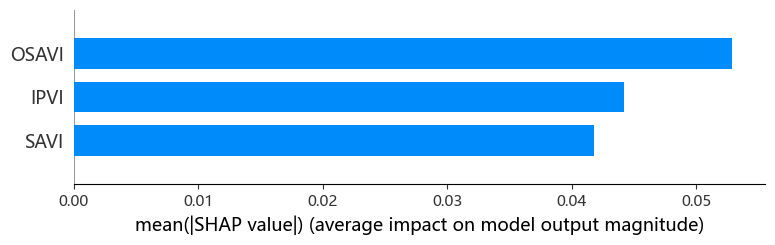

图形已保存至: E:\论文5\a\特征优化 EWM\0610\SHAP\0610.png


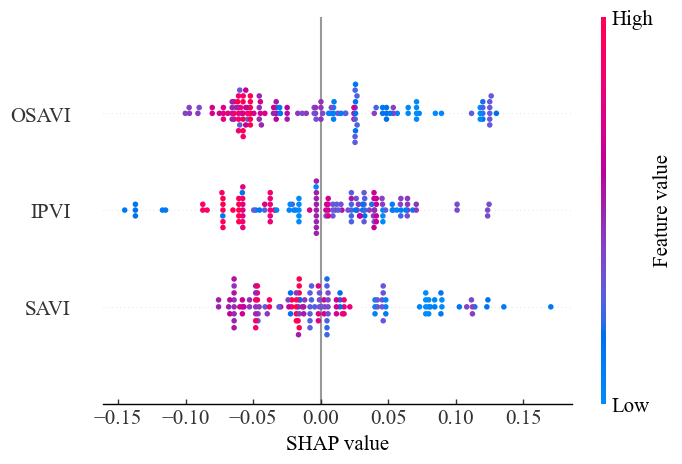

In [53]:
#0610：['B3', 'B4', 'B6', 'MSAVI', 'MSR', 'NDVI', 'OSAVI', 'RDVI', 'SAVI']
#0630：['B6', 'CI', 'DVI', 'GI', 'NDVI']
#0820：['B3', 'B4', 'B6', 'EVI', 'NDVI', 'TVI']
#0908：['CI', 'MSAVI', 'NDVI', 'OSAVI', 'RDVI', 'RVI']
#Total['B3', 'B6', 'DVI', 'MSR', 'NDVI', 'RVI']
df = pd.DataFrame(
    X_train,  # 直接转成 DataFrame
    columns=['IPVI','OSAVI','SAVI']# 列名
)
feature_label=['IPVI','OSAVI','SAVI']
shap.summary_plot(shap_values,X_train,feature_names=feature_label,plot_type='bar')
mean_shap_values = np.abs(shap_values).mean(axis=0)  
features = feature_label
df = pd.DataFrame({'feature_label': feature_label, 'mean_shap_values': mean_shap_values})
with pd.ExcelWriter(r"E:\论文5\a\特征优化 EWM\0610\shap值.xlsx") as writer:
    df.to_excel(writer, sheet_name='Sheet1', index=False)

import os
# 导出高质量的图片
# 创建SHAP解释器
explainer = shap.TreeExplainer(model)

# 计算SHAP值
shap_values = explainer.shap_values(X_train)

# 可视化SHAP值

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['font.size'] = 15  # 设置字体大小为+++++30+++
# 现在创建 SHAP 可视化
#配色   viridis  #配色   viridis  Spectral   coolwarm  RdYlGn  RdYlBu  RdBu  RdGy  PuOr  BrBG PRGn  PiYG 
shap.summary_plot(shap_values, X_train,feature_names=feature_label,show=False)


#------------------------------------SHAP value-------------------------------------
# 获取当前图形的colorbar  
colorbar = plt.gcf().get_axes()[1]  
colorbar.tick_params(labelsize=15)  # 调整colorbar的标签字体大小  

# 调整colorbar的标题和字体大小  
colorbar.set_label('Feature value')  # 设置colorbar的标题  
colorbar.yaxis.label.set_fontsize(15)  # 设置colorbar标题的字体大小 
#colorbar.set_label('Feature value', fontsize=16)  # 设置colorbar的标题和字体大小

# 修改colorbar的颜色  
for label in colorbar.get_yticklabels():  
    label.set_color('black')  # 将colorbar标签颜色设置为黑色  



plt.gcf().set_size_inches(7, 6)
# 修改X轴标题  
plt.xlabel('SHAP value',fontsize=15) 
# 修改X轴和Y轴的颜色和线宽  
plt.gca().spines['bottom'].set_color('black')  # 设置X轴颜色为黑色  
plt.gca().spines['bottom'].set_linewidth(1)  # 设置X轴线宽为1.5   2磅
plt.gca().spines['left'].set_color('black')  # 设置Y轴颜色为黑色  
plt.gca().spines['left'].set_linewidth(1)  # 设置Y轴线宽为1.5  
plt.tick_params(axis='x', direction='in', width=1)  # direction='in'表示向内  
# 调整X轴刻度字体字号大小  
plt.tick_params(axis='x', labelsize=15)  # labelsize设置字体大小
plt.tick_params(axis='y', labelsize=15)  # labelsize设置字体大小
# 获取当前图形中的图例并调整其大小  
if plt.gcf().axes:  
    for ax in plt.gcf().axes:  
        if ax.get_legend() is not None:  # 如果存在图例  
            ax.legend(fontsize=30, loc='best', frameon=True, shadow=True)  # 自定义图例样式  

# 定义保存路径
output_dir = r"E:\论文5\a\特征优化 EWM\0610\SHAP"  # 替换为你的目标文件夹路径
output_path = os.path.join(output_dir, "0610.png")  # 自动处理路径拼接

# 确保文件夹存在
os.makedirs(output_dir, exist_ok=True)
# 保存图形（300 DPI，紧凑布局）
plt.savefig(output_path, dpi=330, bbox_inches='tight')
print(f"图形已保存至: {output_path}")
# 显示图形

In [13]:
###################               验证集          ###############

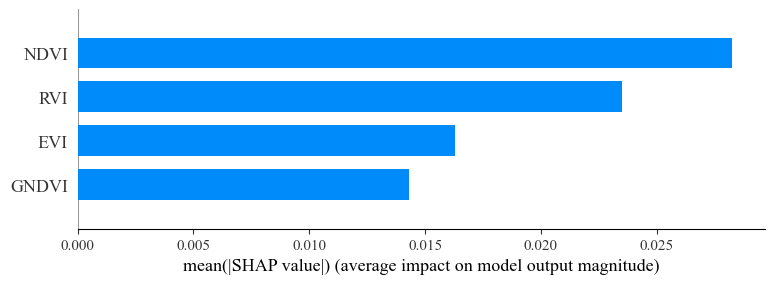

图形已保存至: E:\论文3\基于无人机和XGBoost-SHAP的春玉米长势诊断\SHAP\0630-Test.png


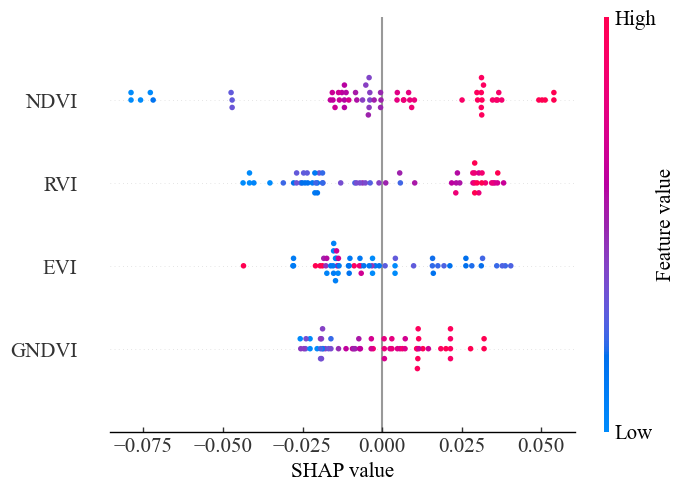

In [14]:
#0610：['B3', 'B4', 'B6', 'MSAVI', 'MSR', 'NDVI', 'OSAVI', 'RDVI', 'SAVI']   'B3', 'B4', 'B6', 'B8', 'CI', 'DVI', 'EVI', 'GI', 'GNDVI','MSAVI', 'MSR', 'NDDI', 'NDVI', 'NGRDI', 'NPCI', 'OSAVI','RDVI', 'RVI', 'SAVI', 'TVI'


feature_label=['EVI', 'GNDVI', 'NDVI', 'RVI']
shap.summary_plot(shap_values,X_test,feature_names=feature_label,plot_type='bar')
##############################(       )################
mean_shap_values = np.abs(shap_values).mean(axis=0)  
features = feature_label
df = pd.DataFrame({'feature_label': feature_label, 'mean_shap_values': mean_shap_values})
with pd.ExcelWriter(r"E:\论文3\基于无人机和XGBoost-SHAP的春玉米长势诊断\SHAP\0630-Test-shap值.xlsx") as writer:
    df.to_excel(writer, sheet_name='Sheet1', index=False)

import os
# 导出高质量的图片
# 创建SHAP解释器
explainer = shap.TreeExplainer(model)

# 计算SHAP值
shap_values = explainer.shap_values(X_test)
###################################(       )################
# 可视化SHAP值

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['font.size'] = 15  # 设置字体大小为12
# 现在创建 SHAP 可视化
#配色   viridis  #配色   viridis  Spectral   coolwarm  RdYlGn  RdYlBu  RdBu  RdGy  PuOr  BrBG PRGn  PiYG 
shap.summary_plot(shap_values, X_test,feature_names=feature_label,show=False)
##############################(       )################

#------------------------------------SHAP value-------------------------------------
# 获取当前图形的colorbar  
colorbar = plt.gcf().get_axes()[1]  
colorbar.tick_params(labelsize=15)  # 调整colorbar的标签字体大小  

# 调整colorbar的标题和字体大小  
colorbar.set_label('Feature value')  # 设置colorbar的标题  
colorbar.yaxis.label.set_fontsize(15)  # 设置colorbar标题的字体大小 
#colorbar.set_label('Feature value', fontsize=16)  # 设置colorbar的标题和字体大小

# 修改colorbar的颜色  
for label in colorbar.get_yticklabels():  
    label.set_color('black')  # 将colorbar标签颜色设置为黑色  



plt.gcf().set_size_inches(7, 6)
# 修改X轴标题  
plt.xlabel('SHAP value',fontsize=15) 
# 修改X轴和Y轴的颜色和线宽  
plt.gca().spines['bottom'].set_color('black')  # 设置X轴颜色为黑色  
plt.gca().spines['bottom'].set_linewidth(1)  # 设置X轴线宽为1.5   2磅
plt.gca().spines['left'].set_color('black')  # 设置Y轴颜色为黑色  
plt.gca().spines['left'].set_linewidth(1)  # 设置Y轴线宽为1.5  
plt.tick_params(axis='x', direction='in', width=1)  # direction='in'表示向内  
# 调整X轴刻度字体字号大小  
plt.tick_params(axis='x', labelsize=15)  # labelsize设置字体大小
plt.tick_params(axis='y', labelsize=15)  # labelsize设置字体大小
# 获取当前图形中的图例并调整其大小  
if plt.gcf().axes:  
    for ax in plt.gcf().axes:  
        if ax.get_legend() is not None:  # 如果存在图例  
            ax.legend(fontsize=15, loc='best', frameon=True, shadow=True)  # 自定义图例样式  

# 定义保存路径
output_dir = r"E:\论文3\基于无人机和XGBoost-SHAP的春玉米长势诊断\SHAP"  # 替换为你的目标文件夹路径
output_path = os.path.join(output_dir, "0630-Test.png")  # 自动处理路径拼接

# 确保文件夹存在
os.makedirs(output_dir, exist_ok=True)
# 保存图形（300 DPI，紧凑布局）
plt.savefig(output_path, dpi=330, bbox_inches='tight')
print(f"图形已保存至: {output_path}")
# 显示图形